In [1]:
import os
import pandas as pd
import numpy as np

In [2]:
from scipy import stats

def perform_welch(list_a, list_b):

    t_stat, p_value = stats.ttest_ind(list_a, list_b, equal_var=False)

    # Significance encoding
    if p_value < 0.001:
        stars = '***'
    elif p_value < 0.01:
        stars = '**'
    elif p_value < 0.05:
        stars = '*'
    else:
        stars = 'ns'

    print(f"Welch's t-test results")
    print(f"t-statistic: {t_stat:.4f}")
    print(f"p-value:     {p_value:.4g}")
    print(f"significance:{stars}")


In [3]:
DATASET = 'fluo'

#### 1. AUC over LNK curve

In [4]:
values_with_effect = []

for fname in os.listdir(f"effects/{DATASET}/with/"):
    data = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = data["LNK"].to_list()

    res = np.trapz(np.array(l))

    values_with_effect.append(res)

values_without_effect = []

for fname in os.listdir(f"effects/{DATASET}/without/"):
    data = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = data["LNK"].to_list()

    res = np.trapz(np.array(l))

    values_without_effect.append(res)

perform_welch(values_with_effect, values_without_effect)

Welch's t-test results
t-statistic: 7.3144
p-value:     0.0001436
significance:***


#### 2. Best LNK value

In [5]:
values_with_effect = []

for fname in os.listdir(f"effects/{DATASET}/with/"):
    data = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = data["LNK"].to_list()

    res = max(l)

    values_with_effect.append(res)

values_without_effect = []

for fname in os.listdir(f"effects/{DATASET}/without/"):
    data = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = data["LNK"].to_list()

    res = max(l)

    values_without_effect.append(res)

perform_welch(values_with_effect, values_without_effect)

Welch's t-test results
t-statistic: 9.3455
p-value:     2.735e-07
significance:***


#### 3. LNK value after first epoch

In [6]:
values_with_effect = []

for fname in os.listdir(f"effects/{DATASET}/with/"):
    data = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = data["LNK"].to_list()

    res = l[0]

    values_with_effect.append(res)

values_without_effect = []
for fname in os.listdir(f"effects/{DATASET}/without/"):
    data = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = data["LNK"].to_list()

    res = l[0]
    values_without_effect.append(res)

perform_welch(values_with_effect, values_without_effect)

Welch's t-test results
t-statistic: -0.6303
p-value:     0.5387
significance:ns


#### 4. LNK value after last measured epoch

In [7]:
values_with_effect = []

for fname in os.listdir(f"effects/{DATASET}/with/"):
    data = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = data["LNK"].to_list()

    res = l[-1]

    values_with_effect.append(res)

values_without_effect = []
for fname in os.listdir(f"effects/{DATASET}/without/"):
    data = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = data["LNK"].to_list()

    res = l[-1]
    values_without_effect.append(res)

perform_welch(values_with_effect, values_without_effect)

Welch's t-test results
t-statistic: 5.4999
p-value:     0.0008815
significance:***


#### 5. LNK value at maximum counterfactual and treatment

In [8]:
values_with_effect = []
indices = []

for fname in os.listdir(f"effects/{DATASET}/with/"):
    data = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = data["LNK"].to_list()

    res = max(l)
    indices.append(l.index(res))

    values_with_effect.append(res)

values_without_effect = []
indexloc = 0
for fname in os.listdir(f"effects/{DATASET}/without/"):
    data = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = data["LNK"].to_list()

    res = l[indices[indexloc]]
    indexloc += 1
    values_without_effect.append(res)

perform_welch(values_with_effect, values_without_effect)

Welch's t-test results
t-statistic: 8.7392
p-value:     8.34e-06
significance:***


In [9]:
values_with_effect = []
indices = []

for fname in os.listdir(f"effects/{DATASET}/without/"):
    data = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = data["LNK"].to_list()

    res = max(l)
    indices.append(l.index(res))

    values_with_effect.append(res)

values_without_effect = []
indexloc = 0
for fname in os.listdir(f"effects/{DATASET}/with/"):
    data = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = data["LNK"].to_list()

    res = l[indices[indexloc]]
    indexloc += 1
    values_without_effect.append(res)

perform_welch(values_with_effect, values_without_effect)

Welch's t-test results
t-statistic: -2.7925
p-value:     0.018
significance:*


#### 6. Per-Epoch t-test

In [10]:
withs = []

for fname in os.listdir(f"effects/{DATASET}/with/"):
    data = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    l = data["LNK"].to_list()
    withs.append(l)

withouts = []
for fname in os.listdir(f"effects/{DATASET}/without/"):
    data = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    l = data["LNK"].to_list()
    withouts.append(l)


withs = np.array(withs)
withouts = np.array(withouts)


for idx in range(300):
    a = list(withs[:, idx])
    b = list(withouts[:, idx])

    t_stat, p_value = stats.ttest_ind(a, b, equal_var=False)

    print(idx, t_stat, p_value, sep='\t')

0	-0.6303077995083595	0.5387238619999923
1	3.4480071673435537	0.004432985421976486
2	1.2007417876915203	0.26438428546591486
3	2.7346711856526746	0.016632327732879783
4	2.4080503758525973	0.03315113462512537
5	6.4672744416138634	1.5725933919521412e-05
6	2.968106588677615	0.01295525181514489
7	5.03285415123741	0.00040680812046141475
8	3.6194666410532412	0.002792876959676914
9	4.4791854179578365	0.0022333794911885306
10	4.451312115505026	0.0015089965411535361
11	3.1815633467518225	0.01408775714621179
12	3.451775133561991	0.003961396369667253
13	2.603593263066191	0.020872642643391615
14	3.3524667564803625	0.005874853185925924
15	3.2241580807265473	0.00694345682945878
16	3.2182826209288606	0.009603342858758105
17	3.3047356051197956	0.011980074166293781
18	3.3764643035036896	0.007056876865674264
19	3.532844162518848	0.005695348927061385
20	3.5498272538037847	0.0037918230906647224
21	4.662821632809789	0.0004270872744005001
22	3.694071259601375	0.004701656503658677
23	6.018404067664632	0.00015

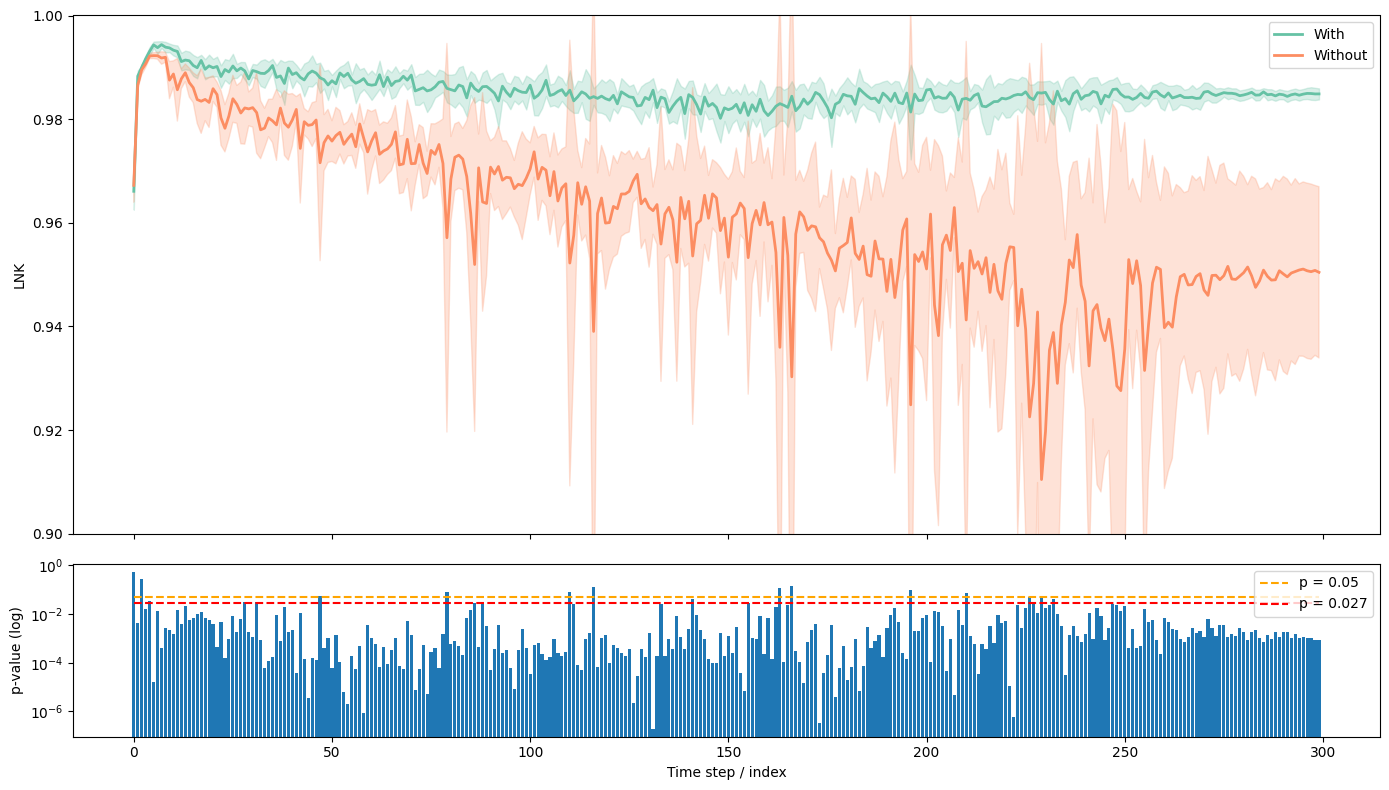

In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats

# -------------------------
# 1) Load your runs (WITH / WITHOUT)
# -------------------------
withs = []
for fname in sorted(os.listdir(f"effects/{DATASET}/with/")):
    df = pd.read_csv(f"effects/{DATASET}/with/{fname}")

    withs.append(df["LNK"].to_numpy())

withouts = []
for fname in sorted(os.listdir(f"effects/{DATASET}/without/")):
    df = pd.read_csv(f"effects/{DATASET}/without/{fname}")

    withouts.append(df["LNK"].to_numpy())

# Ensure all runs have the same length (truncate to min length if not)
minlen = min(min(map(len, withs)), min(map(len, withouts)))
withs = np.stack([x[:minlen] for x in withs], axis=0)       # shape: (n_runs, T)
withouts = np.stack([x[:minlen] for x in withouts], axis=0) # shape: (n_runs, T)

# -------------------------
# 2) Plot helper: mean ± std shading
# -------------------------
cmap = mpl.colormaps["Set2"]
ca, cb = cmap(0), cmap(1)

def plot_mean_shaded(ax, arr2d, color, label):
    """
    arr2d: shape (n_runs, T)
    """
    mean = arr2d.mean(axis=0)
    std  = arr2d.std(axis=0, ddof=0)
    x = np.arange(arr2d.shape[1])

    ax.plot(x, mean, color=color, label=label, linewidth=2)
    ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.25)

# -------------------------
# 3) Compute per-index p-values (Welch by default; set equal_var=True for Student)
# -------------------------
pvals = np.empty(minlen, dtype=float)
tstats = np.empty(minlen, dtype=float)

for idx in range(minlen):
    w = withs[:, idx]
    wo = withouts[:, idx]
    res = stats.ttest_ind(w, wo, equal_var=False, nan_policy="omit")
    tstats[idx] = res.statistic
    pvals[idx]  = res.pvalue

x = np.arange(minlen)

# -------------------------
# 4) Build the combined figure (top: means; bottom: significance)
# -------------------------
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, figsize=(14, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

# --- TOP ---
plot_mean_shaded(ax_top, withs, ca, "With")
plot_mean_shaded(ax_top, withouts, cb, "Without")
ax_top.set_ylabel("LNK")  # or "Score" / your metric name
# Optional: uncomment if you want the same y-limits as your example
# ax_top.set_ylim(0.90, 1.0)
ax_top.legend(loc="best")

# --- BOTTOM ---
ax_bottom.bar(x, pvals)
ax_bottom.set_yscale("log")
ax_bottom.set_ylabel("p-value (log)")
ax_bottom.set_xlabel("Time step / index")

ymin = 0.9
ymax = 1.0

ax_top.set_ylim(ymin, ymax)

# threshold lines
ax_bottom.hlines(0.05, x.min(), x.max(), color="orange", linestyle="--", label="p = 0.05")
ax_bottom.hlines(0.027, x.min(), x.max(), color="red", linestyle="--", label="p = 0.027")
ax_bottom.legend(loc="upper right")

fig.tight_layout()
plt.savefig("fin_time_FLUO.pdf", bbox_inches="tight")
plt.show()
